# XGBOOST MODELS FOR CREDIT EVALUATION

## IMPORTS AND DATA PREPARATION

### IMPORTS

In [1]:
# file-path handling
from pathlib import Path

# Utilities for data management
import numpy as np
import pandas as pd

# XGBoost classifier model class
from xgboost import XGBClassifier


# Evaluation metrics
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    roc_curve,
    precision_recall_curve
)

# Chart plotting
import matplotlib.pyplot as plt
import seaborn as sns

### PATHS

In [2]:
# Paths to train / validate / test data
OUTPUT_DIR = Path("../data")
TRAIN_PATH = OUTPUT_DIR / "train.csv"
VALIDATE_PATH = OUTPUT_DIR / "validate.csv"
TEST_PATH = OUTPUT_DIR / "test.csv"

# Paths to xgboost model outputs
XGBOOST_OUTPUT_DIR = Path("../output/xgboost")
XGBOOST_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

BASELINE_RESULTS_CSV = XGBOOST_OUTPUT_DIR / "xgb_baseline_validation_results.csv"
TUNING_RESULTS_CSV = XGBOOST_OUTPUT_DIR / "xgb_unconstrained_tuning_results_validation.csv"
VALIDATION_COMPARE_CSV = XGBOOST_OUTPUT_DIR / "xgb_unconstrained_validation_comparison.csv"
SELECTED_MODEL_CSV = XGBOOST_OUTPUT_DIR / "xgb_unconstrained_selected_model_validation.csv"


### DATA VALIDATION

In [3]:


# Load data splits to pandas (no low mem for better typing when loading to df)
train_df = pd.read_csv(TRAIN_PATH, low_memory=False)
validate_df = pd.read_csv(VALIDATE_PATH, low_memory=False)
test_df = pd.read_csv(TEST_PATH, low_memory=False)

# Data shape prints (samples, features)
print("Train shape:   ", train_df.shape)
print("Validate shape:", validate_df.shape)
print("Test shape:    ", test_df.shape)

Train shape:    (215137, 33)
Validate shape: (46101, 33)
Test shape:     (46101, 33)


Splits are correct (70% / 15% / 15%)

No. of Features match preprocesing output (33)

In [4]:
# Validate data loaded (after project-level preprocessing - see preprocess-data.ipynb)

# Create resuable constants for label and ID
TARGET_COLUMN = "TARGET"
ID_COLUMN = "SK_ID_CURR"

# Confirm features and order consistent across splits
print("Train/validate columns match:", list(train_df.columns) == list(validate_df.columns))
print("Train/test columns match:    ", list(train_df.columns) == list(test_df.columns))

# Confirm class imbalance (already stratified split)
print("\nDefault rate by split:")
print("Train:   ", train_df[TARGET_COLUMN].mean())
print("Validate:", validate_df[TARGET_COLUMN].mean())
print("Test:    ", test_df[TARGET_COLUMN].mean())

# Check dtypes (esp for categorical features still strings after preprocessing)

# Group for dtype: [list of columns]
dtype_to_columns = (
    train_df.dtypes
    .astype(str)                                # Convert dtype objects to readable strings
    .groupby(train_df.dtypes.astype(str))       # Group columns by dtype
    .apply(lambda s: sorted(s.index.tolist()))  # Collect and sort column names in each dtype group
)

print("\nFeatures by dtype:")
for dtype_name, columns in dtype_to_columns.items():
    print(f"{dtype_name}: {columns}")



Train/validate columns match: True
Train/test columns match:     True

Default rate by split:
Train:    0.08072995347150885
Validate: 0.08073577579662046
Test:     0.08071408429318236

Features by dtype:
float64: ['AMT_ANNUITY', 'AMT_CREDIT', 'AMT_GOODS_PRICE', 'AMT_INCOME_TOTAL', 'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_YEAR', 'CNT_FAM_MEMBERS', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'OWN_CAR_AGE']
int64: ['CNT_CHILDREN', 'DAYS_BIRTH', 'DAYS_ID_PUBLISH', 'EXT_SOURCE_1_MISSING', 'EXT_SOURCE_2_MISSING', 'EXT_SOURCE_3_MISSING', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'SK_ID_CURR', 'TARGET']
str: ['NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'NAME_INCOME_TYPE', 'OCCUPATION_TYPE', 'ORGANIZATION_TYPE']


Cols match
Class imbalance consistent across splits but (!) very pronounced

NOTE: MISSING VALUES with XGBoost

Project-level preprocessing does not remove missing values
- Numerical: NaNs stayed
- Categorical: Replaced by placeholder "MISSING" or imputed from mean and missing flag feature created

XGBoost can handle and use signal from missing values e.g. may learn thinner credit history, discern car ownership etc, so no need to process further



### PREP DATA FOR MODEL TRAINING

##### Separate labels

In [5]:
# Separate labels y
y_train = train_df[TARGET_COLUMN].astype(int).copy()
y_val = validate_df[TARGET_COLUMN].astype(int).copy()
y_test = test_df[TARGET_COLUMN].astype(int).copy()

# Remove labels and IDs to prep samples for training
X_train = train_df.drop(columns=[TARGET_COLUMN, ID_COLUMN]).copy()
X_val = validate_df.drop(columns=[TARGET_COLUMN, ID_COLUMN]).copy()
X_test = test_df.drop(columns=[TARGET_COLUMN, ID_COLUMN]).copy()

# Print shapes (still dfs)
print(f"X_train | shape: {X_train.shape}  | type: {type(X_train)}")
print(f"X_val   | shape: {X_val.shape}    | type: {type(X_val)}")
print(f"X_test  | shape: {X_test.shape}   | type: {type(X_test)}")
print()
print(f"y_train | shape: {y_train.shape}  | type: {type(y_train)}")
print(f"y_val   | shape: {y_val.shape}    | type: {type(y_val)}")
print(f"y_test  | shape: {y_test.shape}   | type: {type(y_test)}")

X_train | shape: (215137, 31)  | type: <class 'pandas.DataFrame'>
X_val   | shape: (46101, 31)    | type: <class 'pandas.DataFrame'>
X_test  | shape: (46101, 31)   | type: <class 'pandas.DataFrame'>

y_train | shape: (215137,)  | type: <class 'pandas.Series'>
y_val   | shape: (46101,)    | type: <class 'pandas.Series'>
y_test  | shape: (46101,)   | type: <class 'pandas.Series'>


##### Convert categorical to one-hot encodings

In [6]:
# Store list of categorical vs num features
categorical_columns = X_train.select_dtypes(include=["object", "string"]).columns.tolist()
numeric_columns = [col for col in X_train.columns if col not in categorical_columns]

# Print and check
print("\n# numeric columns:", len(numeric_columns))
print("Numeric columns:")
print(numeric_columns)

print("\n# categorical columns:", len(categorical_columns))
print("Categorical columns:")
print(categorical_columns)

# One-hot encode categorical columns with pd.get_dumies (including "MISSING")
X_train_encoded = pd.get_dummies(
    X_train,
    columns = categorical_columns,  # Select cat features
    drop_first = False,             # Keep original cat feature for running checks
    dtype=int                       # int type for one-hot encoded features
)

X_val_encoded = pd.get_dummies(
    X_val,
    columns = categorical_columns,  # Select cat features
    drop_first = False,             # Keep original cat feature for running checks
    dtype=int                       # int type for one-hot encoded features
)

X_test_encoded = pd.get_dummies(
    X_test,
    columns = categorical_columns,  # Select cat features
    drop_first = False,             # Keep original cat feature for running checks
    dtype=int                       # int type for one-hot encoded features
)

print("\nEncoded X_train shape:", X_train_encoded.shape)
print("Encoded X_val shape:  ", X_val_encoded.shape)
print("Encoded X_test shape: ", X_test_encoded.shape)


# numeric columns: 25
Numeric columns:
['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'CNT_CHILDREN', 'CNT_FAM_MEMBERS', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_YEAR', 'EXT_SOURCE_1_MISSING', 'EXT_SOURCE_2_MISSING', 'EXT_SOURCE_3_MISSING', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY']

# categorical columns: 6
Categorical columns:
['NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'ORGANIZATION_TYPE']

Encoded X_train shape: (215137, 127)
Encoded X_val shape:   (46101, 126)
Encoded X_test shape:  (46101, 124)


 Features before encoding: Total cat + num features = 31 (correct)

 Note: per above for num features we keep NaNs for XGBoost to handle

 (!) Encoded splits dfs have different # features (due to diff cat values) so need to align next

 ##### Align # features across splits

In [7]:
# Encoded coding split is main schema - no change
X_train_ready = X_train_encoded.copy()

# Rebuild encoded validation and test sets to match train schema (fills with dummy features full of zeroes)
X_val_ready = X_val_encoded.reindex(columns=X_train_ready.columns, fill_value=0)
X_test_ready = X_test_encoded.reindex(columns=X_train_ready.columns, fill_value=0)

# Check #features match across splits
print("Train/validate columns match:", list(X_train_ready.columns) == list(X_val_ready.columns))
print("Train/test columns match:    ", list(X_train_ready.columns) == list(X_test_ready.columns))
print("\nFinal shapes:")
print("X_train_ready:", X_train_ready.shape)
print("X_val_ready:  ", X_val_ready.shape)

Train/validate columns match: True
Train/test columns match:     True

Final shapes:
X_train_ready: (215137, 127)
X_val_ready:   (46101, 127)


In [8]:
# Check no object/string columns left
for split, X in {
    "train": X_train_ready,
    "validate": X_val_ready,
    "test": X_test_ready,
}.items():
    # Group for dtype: [list of columns]
    dtype_to_columns = (
        X.dtypes
        .astype(str)                                # Convert dtype objects to readable strings
        .groupby(X.dtypes.astype(str))              # Group columns by dtype
        .apply(lambda s: sorted(s.index.tolist()))  # Collect and sort column names in each dtype group
    )
    print(f"\n{split} features by dtype:")
    for dtype_name, columns in dtype_to_columns.items():
        print(f"{dtype_name}: {columns}")

# Store final cols orders (for when intorducing monotonic constraint)
feature_names = X_train_ready.columns.tolist()



train features by dtype:
float64: ['AMT_ANNUITY', 'AMT_CREDIT', 'AMT_GOODS_PRICE', 'AMT_INCOME_TOTAL', 'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_YEAR', 'CNT_FAM_MEMBERS', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'OWN_CAR_AGE']
int64: ['CNT_CHILDREN', 'DAYS_BIRTH', 'DAYS_ID_PUBLISH', 'EXT_SOURCE_1_MISSING', 'EXT_SOURCE_2_MISSING', 'EXT_SOURCE_3_MISSING', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_EDUCATION_TYPE_Academic degree', 'NAME_EDUCATION_TYPE_Higher education', 'NAME_EDUCATION_TYPE_Incomplete higher', 'NAME_EDUCATION_TYPE_Lower secondary', 'NAME_EDUCATION_TYPE_Secondary / secondary special', 'NAME_FAMILY_STATUS_Civil marriage', 'NAME_FAMILY_STATUS_Married', 'NAME_FAMILY_STATUS_Separated', 'NAME_FAMILY_STATUS_Single / not married', 'NAME_FAMILY_STATUS_Unknown', 'NAME_FAMILY_STATUS_Widow', 'NAME_HOUSING_TYPE_Co-o

Confirmed: Cols are all numerical

Col order stored for constrained model

Ready for training

## EVALUATION METRICS

(Note: Same for constrained and unconstrained models)

### Kolmogorov-Smirnov (KS) Stat

Very common in credit scoring. Measures point where model does the best job of separating defaulters from good borrowers.Ie. “Can this model separate higher-risk borrowers from lower-risk borrowers?”

In [9]:
# Helper func to compute KS stat for binary classification
def compute_ks(y_true, y_score):
    """
    Returns maximum absolute separation between those two curves as float

    """
    # Convert inputs to pd series for sorting and cumm sum
    df_ks = pd.DataFrame({
        "y_true": pd.Series(y_true).reset_index(drop=True),
        "y_score": pd.Series(y_score).reset_index(drop=True)
    })

    # Sort descending by predicted score to move from highest to lowest risk obseraobservations
    df_ks = df_ks.sort_values("y_score", ascending=False).reset_index(drop=True)

    # Count total positives and negatives
    total_positives = (df_ks["y_true"] == 1).sum()
    total_negatives = (df_ks["y_true"] == 0).sum()

    # defensive code for cases where one class is missing
    if total_positives == 0 or total_negatives == 0:
        return np.nan

    # Build cumulative positive and negative shares
    df_ks["cum_positives"] = (df_ks["y_true"] == 1).cumsum() / total_positives
    df_ks["cum_negatives"] = (df_ks["y_true"] == 0).cumsum() / total_negatives

    # Store KS as maximum gap between cumulative curves
    ks_stat = np.max(np.abs(df_ks["cum_positives"] - df_ks["cum_negatives"]))

    return ks_stat

### Eval Helpers

##### Compute metrics

Helper func to evaluate fitted model with metrics:
- ROC-AUC: how well model ranks true defaulters over non-defaulters across classification thresholds
- PR-AUC: tradeoff between precision and recall (esp important here given class imbalance (rare defaults))
- Brier Score: how close predicted default probabilities are to actual outcomes
- KS Statistic: per above, maximum separation between cumulative distributions of defaulters and non-defaulters when ranked by predicted risk

In [10]:

def evaluate_binary_model(model, X, y, split_name, model_name):
    """
    Evaluates trained model, returns dict with metrics and metadata
    (Uses sklearn.metrics methods imported above to compute metrics)
    """
    # Predict probabilities for the positive class (default = 1)
    y_proba = model.predict_proba(X)[:, 1]

    # Compute eval metrics
    roc_auc = roc_auc_score(y, y_proba)
    pr_auc = average_precision_score(y, y_proba)
    brier = brier_score_loss(y, y_proba)
    ks = compute_ks(y, y_proba)

    # Extract best boosting iteration (incl with early stopping)
    # Ie boosting round at which validation performance peaked before training stopped improving
    best_iteration = getattr(model, "best_iteration", None)

    result_dict = {
        "model_name": model_name,
        "split": split_name,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "brier_score": brier,
        "ks_stat": ks,
        "best_iteration": best_iteration
    }

    return result_dict

##### Plots

In [11]:
# ROC curves
def plot_roc_curves(curves_dict, title):

    plt.figure(figsize=(8, 6))

    for label, (y_true, y_proba) in curves_dict.items():
        fpr, tpr, _ = roc_curve(y_true, y_proba)
        auc_value = roc_auc_score(y_true, y_proba)

        # Plot each ROC curve with its AUC in the legend
        plt.plot(fpr, tpr, label=f"{label} (AUC = {auc_value:.4f})")

    # Plot the random-classifier diagonal baseline
    plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


# Precision-Recall curves
def plot_pr_curves(curves_dict, title):

    plt.figure(figsize=(8, 6))

    for label, (y_true, y_proba) in curves_dict.items():
        precision, recall, _ = precision_recall_curve(y_true, y_proba)
        pr_auc_value = average_precision_score(y_true, y_proba)

        # Plot each PR curve with its average precision in the legend
        plt.plot(recall, precision, label=f"{label} (PR-AUC = {pr_auc_value:.4f})")

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()



# Plot a simple bar chart comparing metrics across models to compare
# - baselines vs tuned
# - unconstrained vs constrained
def plot_metric_comparison(results_df, split_name, metric_name, title):

    plot_df = results_df[results_df["split"] == split_name].copy()

    plt.figure(figsize=(8, 5))
    sns.barplot(data=plot_df, x="model_name", y=metric_name)

    plt.title(title)
    plt.xlabel("Model")
    plt.ylabel(metric_name)
    plt.xticks(rotation=20)
    plt.grid(True, axis="y", alpha=0.3)
    plt.show()

## UNCONSTRAINED XGBOOST MODEL

### First Trainning Run (No Hyperparameter Tuning)

In [12]:
# Define first-pass unconstrained XGBoost baseline model
xgb_baseline = XGBClassifier(
    objective="binary:logistic",    # Setting goal as binary pred
    eval_metric="aucpr",            # PR-AUC as primary eval metric given class imbalance (others computed with helpers outside)
    n_estimators=1000,              # Max no. of trees wide (sequential boosting rounds) (set high to likely let early stopping control actual num)
    early_stopping_rounds=50,       # Stop early after n rounds if validation metric doesn't improve
    learning_rate=0.05,             # Scaling factor applied to each new tree's contribution to the final prediction (step size)
    max_depth=4,                    # Max no. of trees deep (set low for xgboost - focus on sequential improvement ie estimators vs deep complexity)
    min_child_weight=5,             # Only create new branch big enough group of samples
    subsample=0.8,                  # Fraction of sample rows sampled for each boosting round (adds regularization / reduces overfitting)
    colsample_bytree=0.8,           # Fraction of features sampled when building each tree (also adds regularization / reduces overfitting)
    reg_lambda=1.0,                 # L2 regularization strength on leaf weights (higher = more shrinkage / less overfitting)
    tree_method="hist",             # Use histogram-based tree construction (faster / more efficient for large tabular datasets)
    device="cuda",                  # Use GPU
    random_state=42,                # Seed for reproducibility
    n_jobs=-1                       # Use all available CPU threads (inly for CPU-side work (per above gpu used in paralalizable training))
)

# Fit unconstrained baseline model using validation set for early stopping
xgb_baseline.fit(
    X_train_ready,
    y_train,
    eval_set=[(X_val_ready, y_val)],  # Validation set used for early stopping
    verbose=False                     # Keep notebook output clean
)


# Print boosting round at which validation performance was best under early stopping
# I.e. how many trees were useful before further boosting stopped helping
print(f"Baseline best iteration: {xgb_baseline.best_iteration}")

# Print highest validation PR-AUC reached
print(f"Baseline best score: {xgb_baseline.best_score}")

# Store predicted probabilities to plot ROC and PR curves
baseline_val_prob = xgb_baseline.predict_proba(X_val_ready)[:, 1]

Baseline best iteration: 830
Baseline best score: 0.23651913400539737


/home/jlsm/ml/credit-risk-model-constraint-eval/venv/lib/python3.13/site-packages/xgboost/core.py:751: UserWarning: [19:37:29] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


In [13]:
# Evaluate the fitted baseline on validation split pre-hyperparam-tuning
baseline_val_result = evaluate_binary_model(
    model=xgb_baseline,
    X=X_val_ready,
    y=y_val,
    split_name="validation",
    model_name="xgb_unconstrained_baseline"
)

results_df = pd.DataFrame([baseline_val_result])

# Save baseline validation results to CSV
results_df.to_csv(BASELINE_RESULTS_CSV, index=False)
print("Saved: xgb_baseline_validation_results.csv")

results_df

Saved: xgb_baseline_validation_results.csv


,model_name,split,roc_auc,pr_auc,brier_score,ks_stat,best_iteration
0,xgb_unconstrained_baseline,validation,0.753768,0.236797,0.068078,0.376673,830


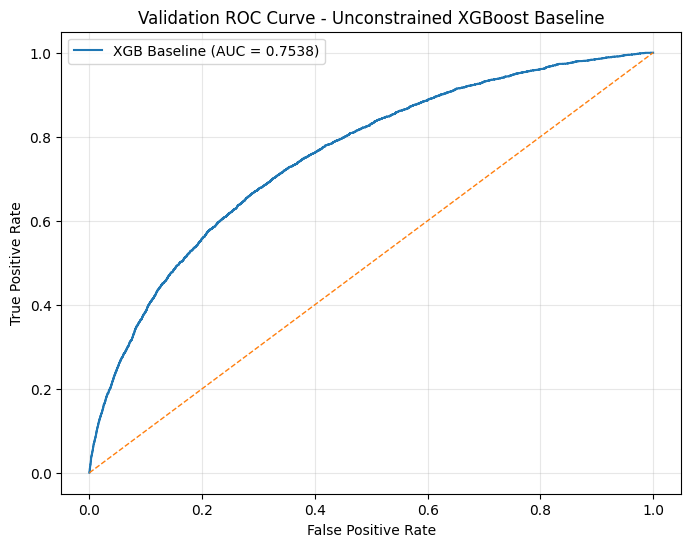

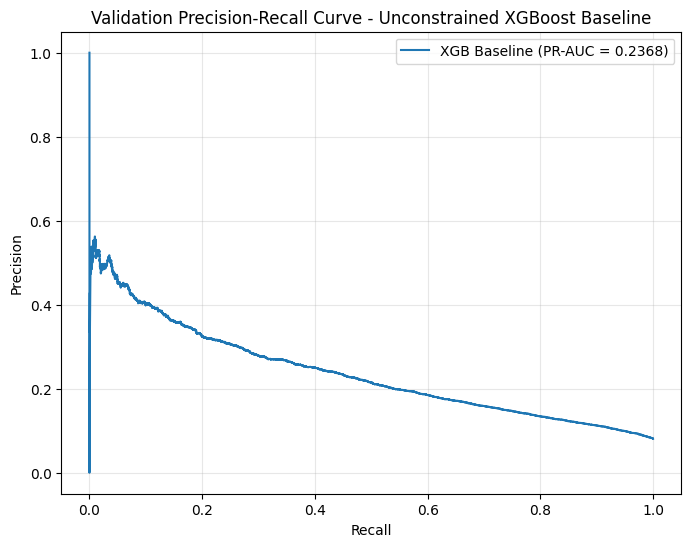

In [14]:
# Plot ROC and PR curves for the untuned baseline model on the validation set
plot_roc_curves(
    curves_dict={
        "XGB Baseline": (y_val, baseline_val_prob)
    },
    title="Validation ROC Curve - Unconstrained XGBoost Baseline"
)

plot_pr_curves(
    curves_dict={
        "XGB Baseline": (y_val, baseline_val_prob)
    },
    title="Validation Precision-Recall Curve - Unconstrained XGBoost Baseline"
)

### Hyperparameter Tuning

##### Approach:

Two-stage tuning design:

**Two-stage hyperparameter tuning strategy:**

First, we tune the main tree-complexity controls:

* max_depth
* min_child_weight

These parameters most directly determine how locally complex each tree can become and how easily the model creates additional tree splits, so they are the main controls over whether the model underfits by being too rigid or overfits by learning patterns that are too specific to the training data.

Then, we fix the optimal values for max_depth and min_child_weight and tune the main boosting and regularization controls:

* learning_rate
* subsample
* colsample_bytree
* reg_lambda

This staged design is intended to separate two related but conceptually distinct questions:

* first, what level of tree complexity is appropriate for this dataset?
* second, given that tree-complexity level, how aggressively and how regularized should boosting proceed?

We considered broader search procedures, including libraries such as BayesSearchCV, for a more exhaustive parameter search. We did not use them here for two main reasons:

* First, all model selection in this notebook is based on a single validation data split. A much broader search over that same split would increase the risk that the selected hyperparameters partly overfit to validation data specific noise rather than a genuinely better underlying configuration.

* Second, a very broad search would make the benchmark construction harder to explain. The project’s main objective is the constrained-versus-unconstrained comparison, so the tuning must remain interpretable: first selecting tree-complexity controls, then tuning boosting and regularization.

We believe this design is appropriate for our research question because the objective is not to produce the most fully optimized XGBoost possible in isolation. The objective is to establish a strong unconstrained benchmark and then compare it on an apples-to-apples basis against a constrained version trained on the same data, feature set, and evaluation protocol. Using one shared validation data split makes that comparison direct and transparent: every unconstrained candidate is judged under the same selection environment, and the final constrained-versus-unconstrained comparison is not complicated by differences in resampling outcomes across folds.

In [ ]:
def train_and_evaluate_xgb_candidate(candidate_params, candidate_name):
    """
    Helper func to train one unconstrained XGBoost candidate on the training split,
    use the validation split for early stopping,
    and return both the fitted model and its validation metrics.

    Returns fitted model instance and validation results dict

    """

    # Build candidate model with candidate-specific hyperparameter values
    fitted_model = XGBClassifier(
        objective="binary:logistic",             # Binary classification: predict probability of default
        eval_metric="aucpr",                     # PR-AUC is the early-stopping metric because defaults are rare
        n_estimators=1000,                       # Large cap on boosting rounds; early stopping will stop earlier if needed
        early_stopping_rounds=50,                # Stop if validation PR-AUC does not improve for 50 rounds
        tree_method="hist",                      # Efficient histogram-based tree construction
        device="cuda",                           # Train on GPU
        random_state=42,                         # Reproducibility
        n_jobs=-1,                               # Use available CPU threads where relevant
        **candidate_params                       # Insert the hyperparameters being tested
    )

    # Fit on training data while monitoring validation performance
    fitted_model.fit(
        X_train_ready,
        y_train,
        eval_set=[(X_val_ready, y_val)],         # Validation split used for early stopping
        verbose=False                            # Keep notebook output compact
    )

    # Evaluate candidate on validation using helper defined in eval section
    validation_result = evaluate_binary_model(
        model=fitted_model,
        X=X_val_ready,
        y=y_val,
        split_name="validation",
        model_name=candidate_name
    )

    # Add metadata to help interpret search results.
    validation_result["best_iteration"] = fitted_model.best_iteration
    validation_result["best_score"] = fitted_model.best_score

    # Store each hyperparameter value in results row to complete results df
    for param_name, param_value in candidate_params.items():
        validation_result[param_name] = param_value

    return fitted_model, validation_result

In [ ]:

# Define hyperparameter value search space

# We vary the most important knobs:
# - learning_rate: how aggressively each new tree updates the model
# - max_depth: maximum tree depth
# - min_child_weight: minimum weight required to split further
# - subsample: row sampling per tree
# - colsample_bytree: feature sampling per tree
# - reg_lambda: L2 regularization on leaf weights
#
# The grid is intentionally small:
# - systematic enough to be defensible
# - small enough to keep runtime reasonable
# - sufficient for establishing a strong benchmark model
# -------------------------------------------------------------------
from itertools import product

xgb_search_grid = {
    "learning_rate": [0.03, 0.05],      # how aggressively each new tree updates the model
    "max_depth": [3, 4],                # maximum tree depth
    "min_child_weight": [3, 5],         # minimum weight required to split further
    "subsample": [0.7, 0.8],            # row sampling per tree
    "colsample_bytree": [0.7, 0.8],     # feature sampling per tree
    "reg_lambda": [1.0, 2.0]            # L2 regularization on leaf weights
}

# Build the full Cartesian product of the grid so every combination
# is evaluated systematically.
search_param_names = list(xgb_search_grid.keys())
search_combinations = list(product(*xgb_search_grid.values()))

print(f"Number of candidate combinations: {len(search_combinations)}")

Number of candidate combinations: 64


In [ ]:
# Run hyperparameter search - Step 1:
# - fit each candidate on the training split
# - evaluate each candidate on the validation split
# - rank candidates using validation metrics only

search_results = []
search_models = {}

for i, combo in enumerate(search_combinations, start=1):
    # Map tuple back to a named parameter dictionary
    candidate_params = dict(zip(search_param_names, combo))

    # Create a readable label so we can trace results later
    candidate_name = f"xgb_search_candidate_{i}"

    # Train candidate and evaluate it on validation
    fitted_model, validation_result = train_and_evaluate_xgb_candidate(
        candidate_params=candidate_params,
        candidate_name=candidate_name
    )

    # Store fitted model so we can retrieve the winner later
    search_models[candidate_name] = fitted_model

    # Store validation metrics and metadata for comparison
    search_results.append(validation_result)

# Convert results to a dataframe for inspection
search_results_df = pd.DataFrame(search_results)

# Sort candidates by PR-AUC first
search_results_df = search_results_df.sort_values(
    by=["pr_auc", "roc_auc", "ks_stat", "brier_score"],
    ascending=[False, False, False, True]
).reset_index(drop=True)

# Show top results
search_results_df.head(10)

,model_name,split,roc_auc,pr_auc,brier_score,ks_stat,best_iteration,best_score,learning_rate,max_depth,min_child_weight,subsample,colsample_bytree,reg_lambda
0,xgb_search_candidate_56,validation,0.754188,0.237661,0.068052,0.378648,829,0.237362,0.05,4,3,0.8,0.8,2.0
1,xgb_search_candidate_54,validation,0.753817,0.237319,0.068052,0.379550,856,0.237062,0.05,4,3,0.8,0.7,2.0
2,xgb_search_candidate_50,validation,0.754553,0.236969,0.068063,0.380278,683,0.236685,0.05,4,3,0.7,0.7,2.0
3,xgb_search_candidate_17,validation,0.754405,0.236839,0.068070,0.378666,999,0.236554,0.03,4,3,0.7,0.7,1.0
4,xgb_search_candidate_63,validation,0.753768,0.236797,0.068078,0.376673,830,0.236519,0.05,4,5,0.8,0.8,1.0
5,xgb_search_candidate_51,validation,0.754157,0.236697,0.068076,0.376106,673,0.236411,0.05,4,3,0.7,0.8,1.0
6,xgb_search_candidate_58,validation,0.754128,0.236684,0.068083,0.378500,683,0.236403,0.05,4,5,0.7,0.7,2.0
7,xgb_search_candidate_18,validation,0.754552,0.236643,0.068075,0.378251,999,0.236363,0.03,4,3,0.7,0.7,2.0
8,xgb_search_candidate_61,validation,0.753627,0.236565,0.068091,0.376645,819,0.236292,0.05,4,5,0.8,0.7,1.0
9,xgb_search_candidate_21,validation,0.754290,0.236536,0.068067,0.377595,999,0.236271,0.03,4,3,0.8,0.7,1.0


In [ ]:
# Save the full unconstrained XGBoost tuning table with:
# - every candidate hyperparameter combination
# - validation metrics for each candidate
# - best_iteration and best_score from early stopping

search_results_df.to_csv(TUNING_RESULTS_CSV, index=False)
print(f"Saved: {TUNING_RESULTS_CSV}")

Saved: ../output/xgboost/xgb_unconstrained_tuning_results_validation.csv


In [ ]:
# Select best unconstrained model (already sorted so first row is most performant model)

best_unconstrained_name = search_results_df.loc[0, "model_name"]
best_xgb_unconstrained = search_models[best_unconstrained_name]

print("Selected tuned unconstrained XGBoost model:")
print(f"- Candidate name: {best_unconstrained_name}")
print(f"- Validation PR-AUC: {search_results_df.loc[0, 'pr_auc']:.6f}")
print(f"- Validation ROC-AUC: {search_results_df.loc[0, 'roc_auc']:.6f}")
print(f"- Validation KS: {search_results_df.loc[0, 'ks_stat']:.6f}")
print(f"- Validation Brier: {search_results_df.loc[0, 'brier_score']:.6f}")
print(f"- Best boosting iteration: {best_xgb_unconstrained.best_iteration}")
print(f"- Best XGBoost validation score: {best_xgb_unconstrained.best_score}")

Selected tuned unconstrained XGBoost model
------------------------------------------
Candidate name: xgb_search_candidate_56
Validation PR-AUC: 0.237661
Validation ROC-AUC: 0.754188
Validation KS: 0.378648
Validation Brier: 0.068052
Best boosting iteration: 829
Best XGBoost validation score: 0.23736154325376507


In [ ]:
# Save single selected tuned unconstrained model row (used later in constrained model comparison)
best_unconstrained_row_df = search_results_df.head(1).copy()
best_unconstrained_row_df.to_csv(SELECTED_MODEL_CSV, index=False)
print(f"Saved: {SELECTED_MODEL_CSV}")

Saved: ../output/xgboost/xgb_unconstrained_selected_model_validation.csv


In [ ]:
# Evaluate tuned unconstrained model on validation for comparison against  original unconstrained baseline
tuned_val_result = evaluate_binary_model(
    model=best_xgb_unconstrained,
    X=X_val_ready,
    y=y_val,
    split_name="validation",
    model_name="xgb_unconstrained_tuned"
)

# Store validation predicted probabilities for comparison plots
tuned_val_prob = best_xgb_unconstrained.predict_proba(X_val_ready)[:, 1]

# Build a validation-only comparison table
validation_compare_df = pd.DataFrame([
    baseline_val_result,
    tuned_val_result
])

validation_compare_df

,model_name,split,roc_auc,pr_auc,brier_score,ks_stat,best_iteration
0,xgb_unconstrained_baseline,validation,0.753768,0.236797,0.068078,0.376673,830
1,xgb_unconstrained_tuned,validation,0.754188,0.237661,0.068052,0.378648,829


In [ ]:
# Save the validation comparison between:
# - original unconstrained baseline
# - tuned unconstrained XGBoost
validation_compare_df.to_csv(VALIDATION_COMPARE_CSV, index=False)
print(f"Saved: {VALIDATION_COMPARE_CSV}")

Saved: ../output/xgboost/xgb_unconstrained_validation_comparison.csv


### Interpretation

The joint hyperparameter search produced a modest but consistent improvement over the original unconstrained baseline on the validation split.

Compared with the baseline, the selected tuned model improved:
- ROC-AUC from **0.753768** to **0.754188**
- PR-AUC from **0.236797** to **0.237661**
- KS statistic from **0.376673** to **0.378648**
- Brier score from **0.068078** to **0.068052** (lower is better)

The improvement is small, but it is directionally consistent across all four metrics. This suggests that the original baseline was already strong, and that the tuning stage successfully identified a slightly better unconstrained benchmark without materially changing the qualitative behavior of the model.

We therefore lock this tuned unconstrained XGBoost specification as the flexible benchmark to be compared next against the constrained XGBoost model.

### Plots

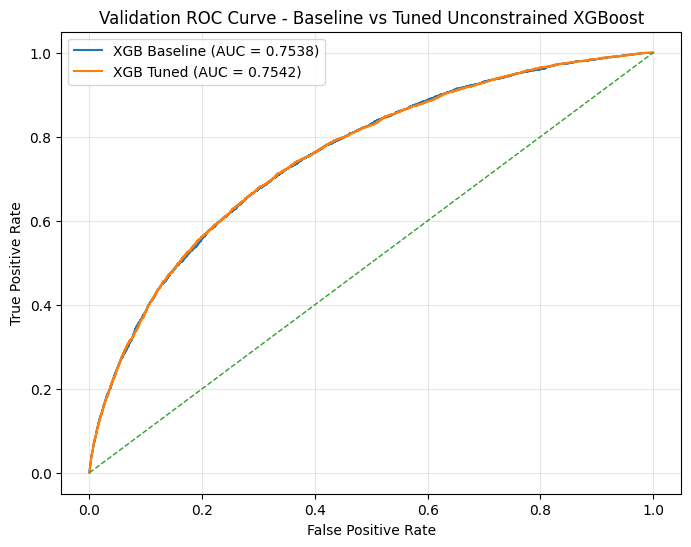

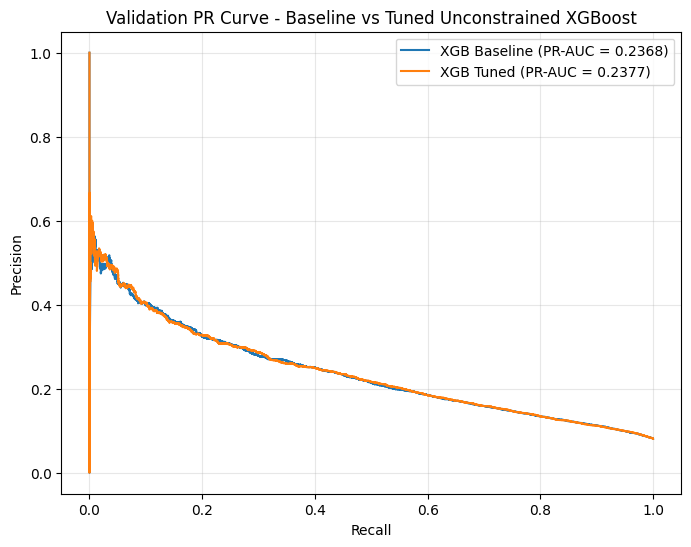

In [ ]:

# Validation comparison plots: ROC & PR for baseline vs tuned unconstrained XGBoost

plot_roc_curves(
    curves_dict={
        "XGB Baseline": (y_val, baseline_val_prob),
        "XGB Tuned": (y_val, tuned_val_prob)
    },
    title="Validation ROC Curve - Baseline vs Tuned Unconstrained XGBoost"
)

plot_pr_curves(
    curves_dict={
        "XGB Baseline": (y_val, baseline_val_prob),
        "XGB Tuned": (y_val, tuned_val_prob)
    },
    title="Validation PR Curve - Baseline vs Tuned Unconstrained XGBoost"
)

In [ ]:
# Display validation-only comparison table
display(validation_compare_df)

,model_name,split,roc_auc,pr_auc,brier_score,ks_stat,best_iteration
0,xgb_unconstrained_baseline,validation,0.753768,0.236797,0.068078,0.376673,830
1,xgb_unconstrained_tuned,validation,0.754188,0.237661,0.068052,0.378648,829


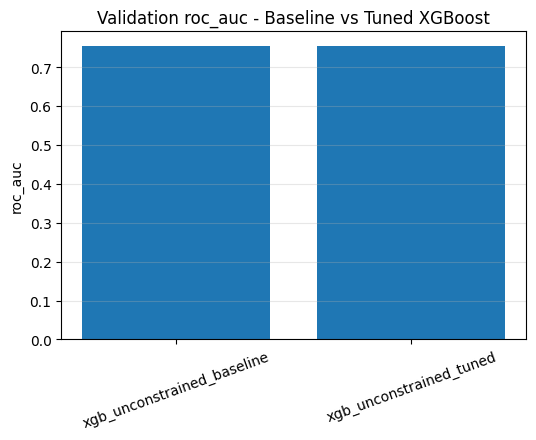

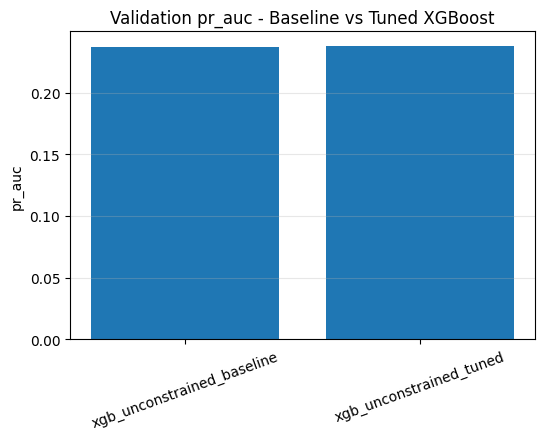

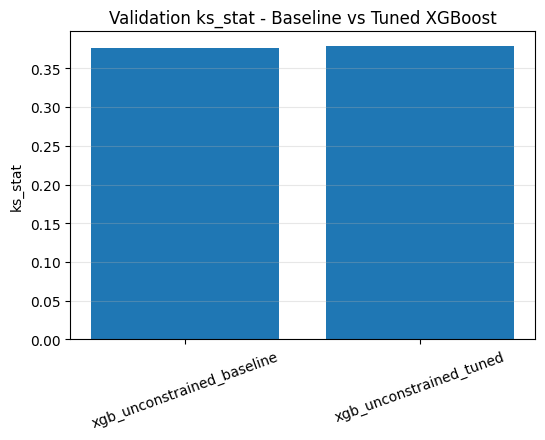

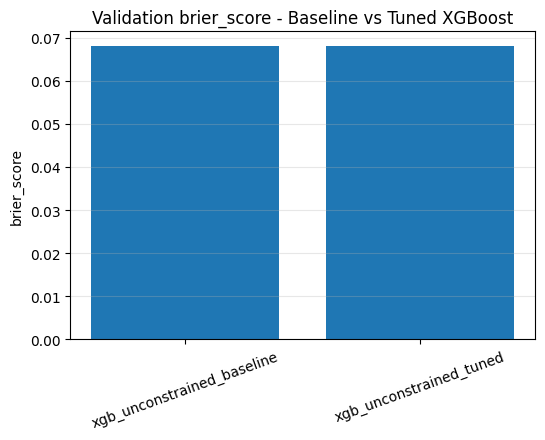

In [ ]:
# Plot simple validation metric comparison bars: baseline vs tuned unconstrained XGBoost
# - higher is better for ROC-AUC, PR-AUC, and KS
# - lower is better for Brier Score

metrics_to_plot = ["roc_auc", "pr_auc", "ks_stat", "brier_score"]

for metric in metrics_to_plot:
    plt.figure(figsize=(6, 4))
    plt.bar(validation_compare_df["model_name"], validation_compare_df[metric])
    plt.title(f"Validation {metric} - Baseline vs Tuned XGBoost")
    plt.ylabel(metric)
    plt.xticks(rotation=20)
    plt.grid(True, axis="y", alpha=0.3)
    plt.show()